[2026-08-05 18:11:03] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-10-31 23:59:59
[2026-08-05 18:11:20] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-10-31 23:59:59
[2026-08-05 18:11:20] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-05 18:11:22] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-05 18:11:23] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-10-31
[2026-08-05 18:11:23] [info     ] ========== 数据检查 ==========
[2026-08-05 18:11:23] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_l

时段,IC
2024-01-15~2024-02-08,-0.0162
2024-09-24~2024-10-08,-0.0099

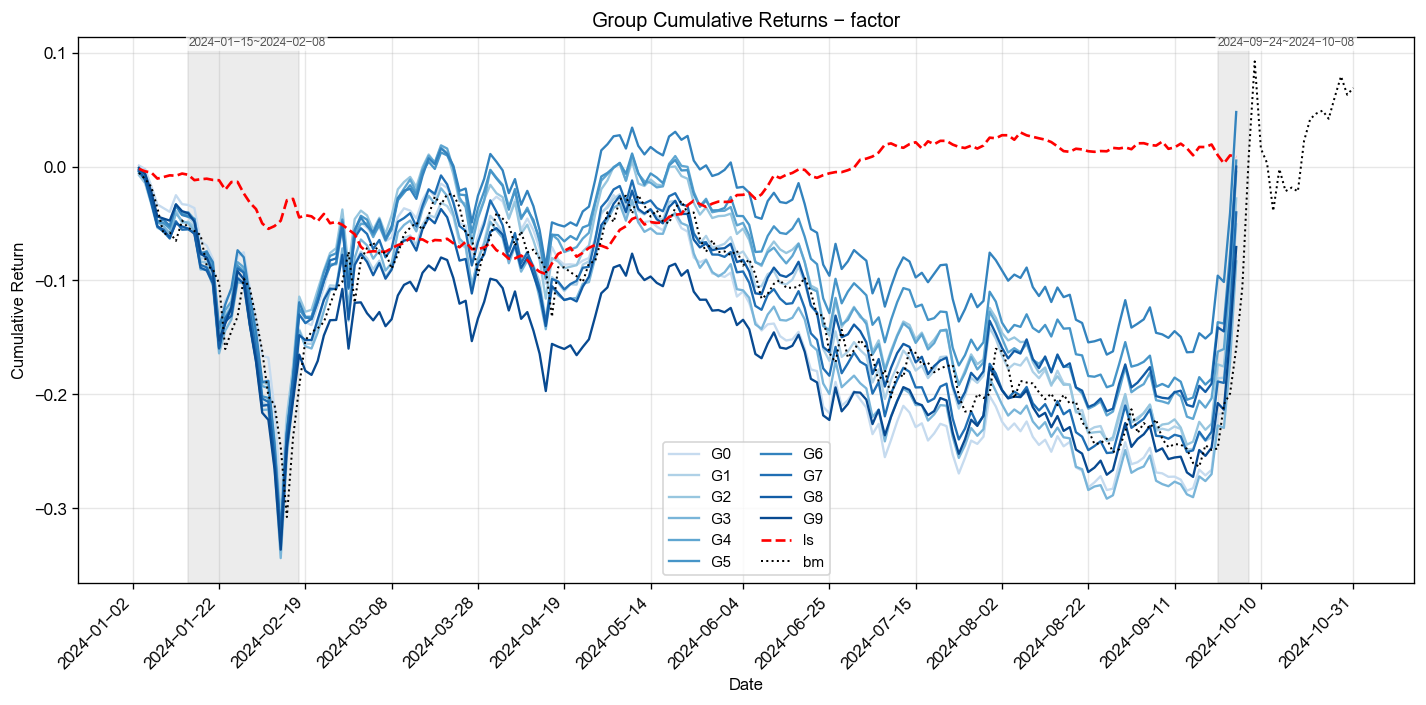
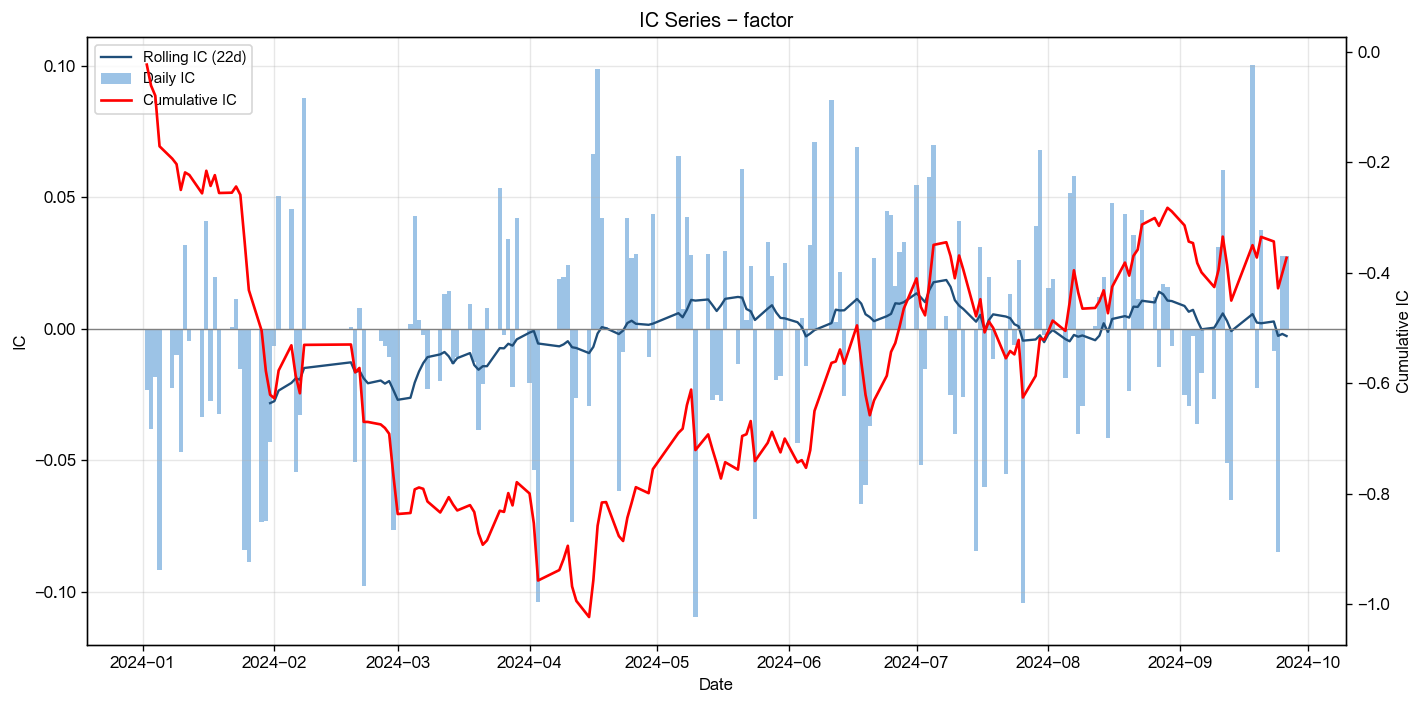
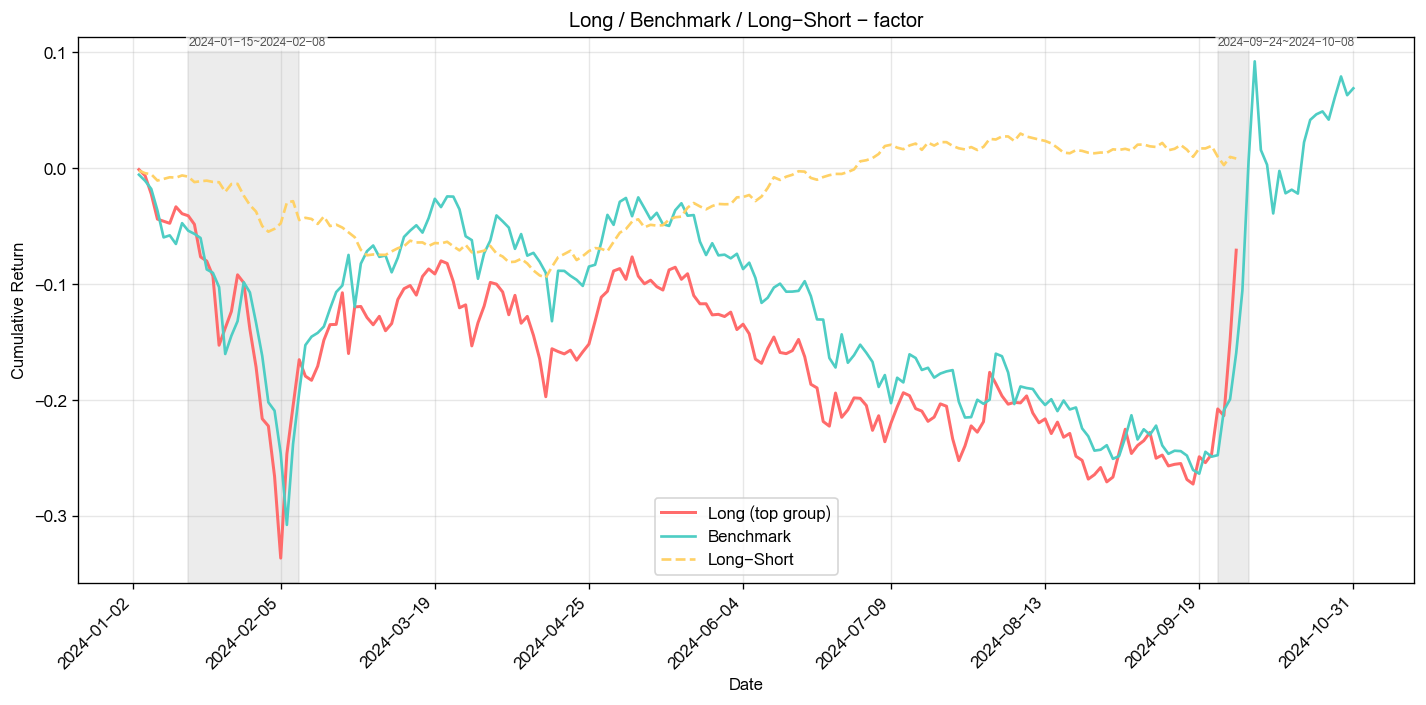
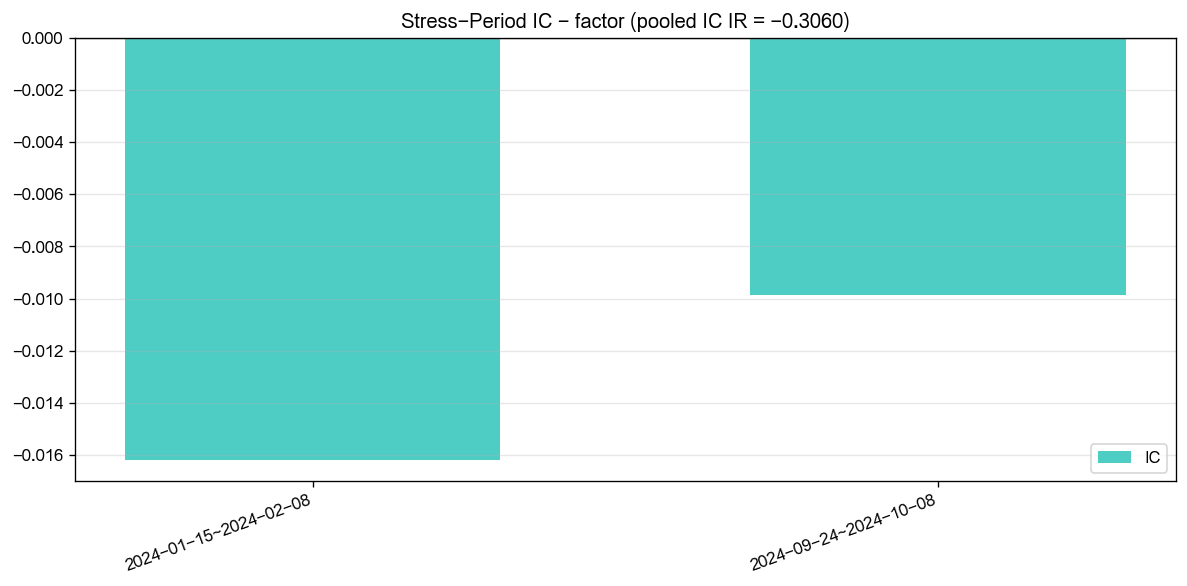
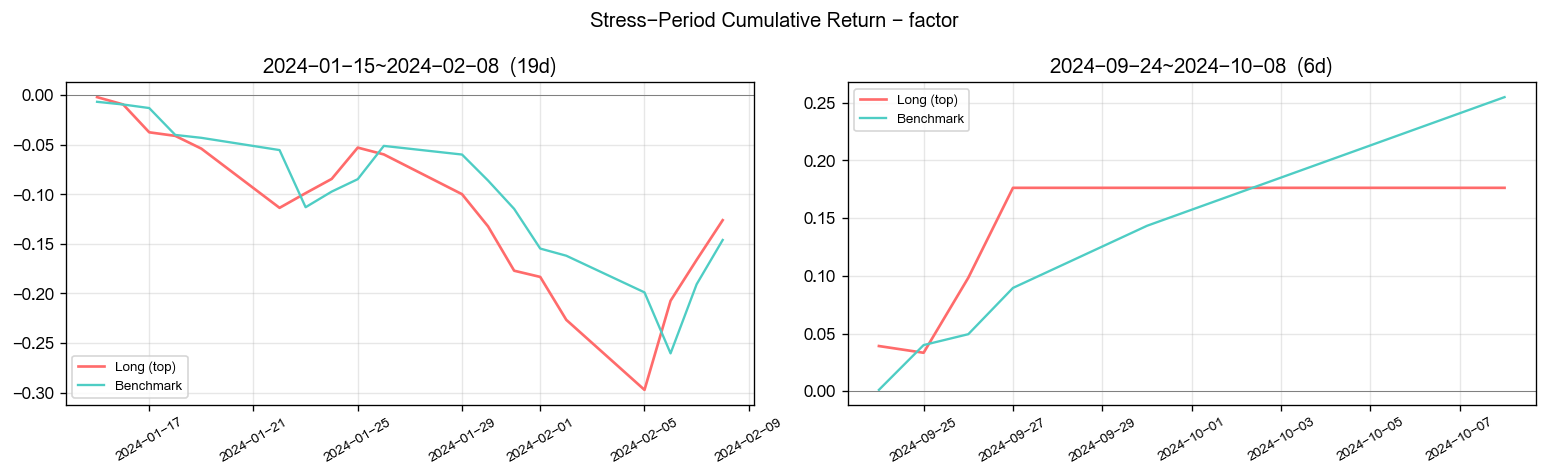

[2026-08-05 18:14:43] [info     ] ========== 因子池回归 ==========
[2026-08-05 18:14:44] [info     ] 加载 T+1 收益数据完成                  end_date=2024-10-31 instrument_count=1106 rows=228070 start_date=2024-01-02
[2026-08-05 18:14:47] [info     ] 获取收益率数据, 耗时: 3.9632 秒
[2026-08-05 18:14:50] [info     ] 滚动 Elastic Net 拟合, 耗时: 3.697 秒
[2026-08-05 18:14:50] [info     ] 统计 回归结果, 耗时: 0.008 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,kdj_d_9_3_3,2.5626,0.0151,0.0059,1.0000
2,netflow_amount_rate_main,2.2654,0.0070,0.0031,1.0000
3,gross_profit_rate_ttm,1.8234,0.0079,0.0043,1.0000
4,amount,1.8206,0.0202,0.0111,1.0000
5,volatility_5,1.8165,0.0231,0.0127,1.0000
6,roa_avg_ttm,1.6580,0.0157,0.0094,0.8571
7,factor,1.6046,0.0067,0.0042,1.0000
8,rsi_12,1.5976,0.0402,0.0252,1.0000
9,macd_dea_12_26_9,1.5555,0.0063,0.0041,0.8571
10,net_profit_rate_ttm,1.5502,0.0045,0.0029,0.8571

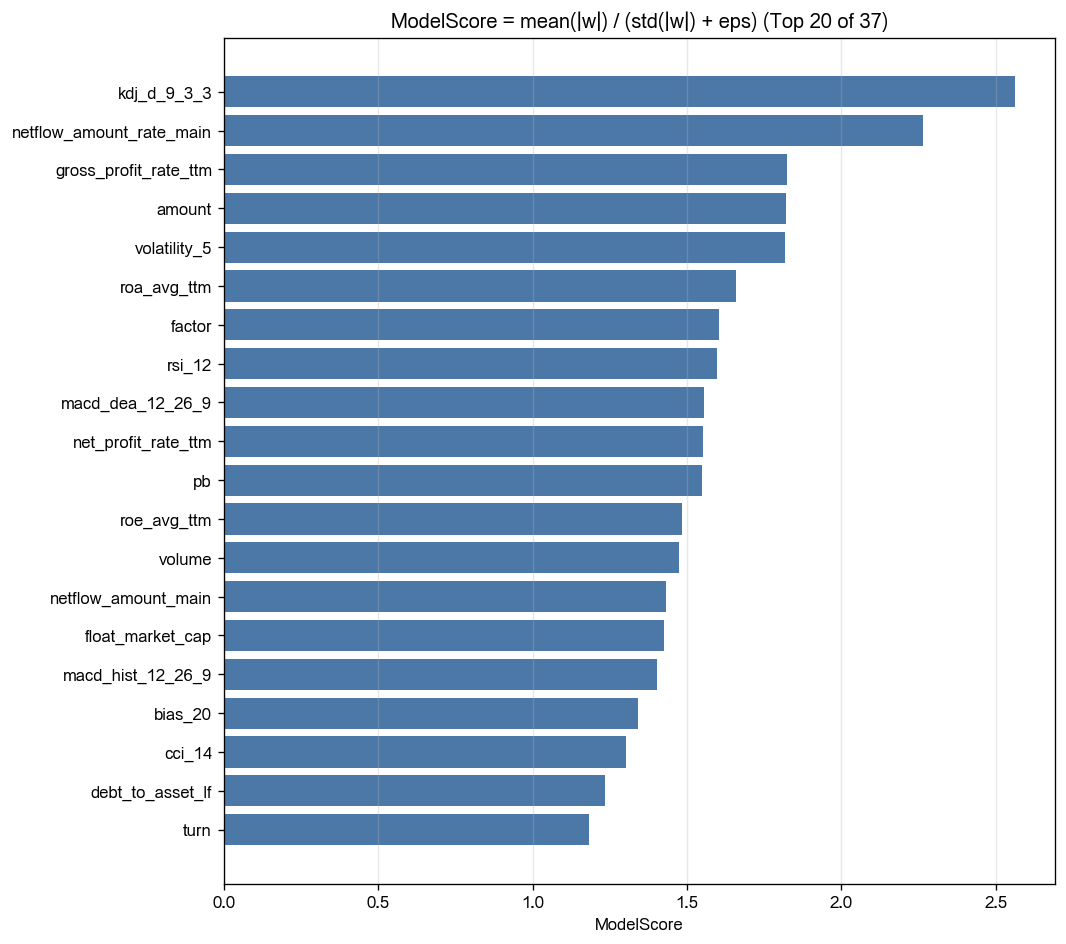
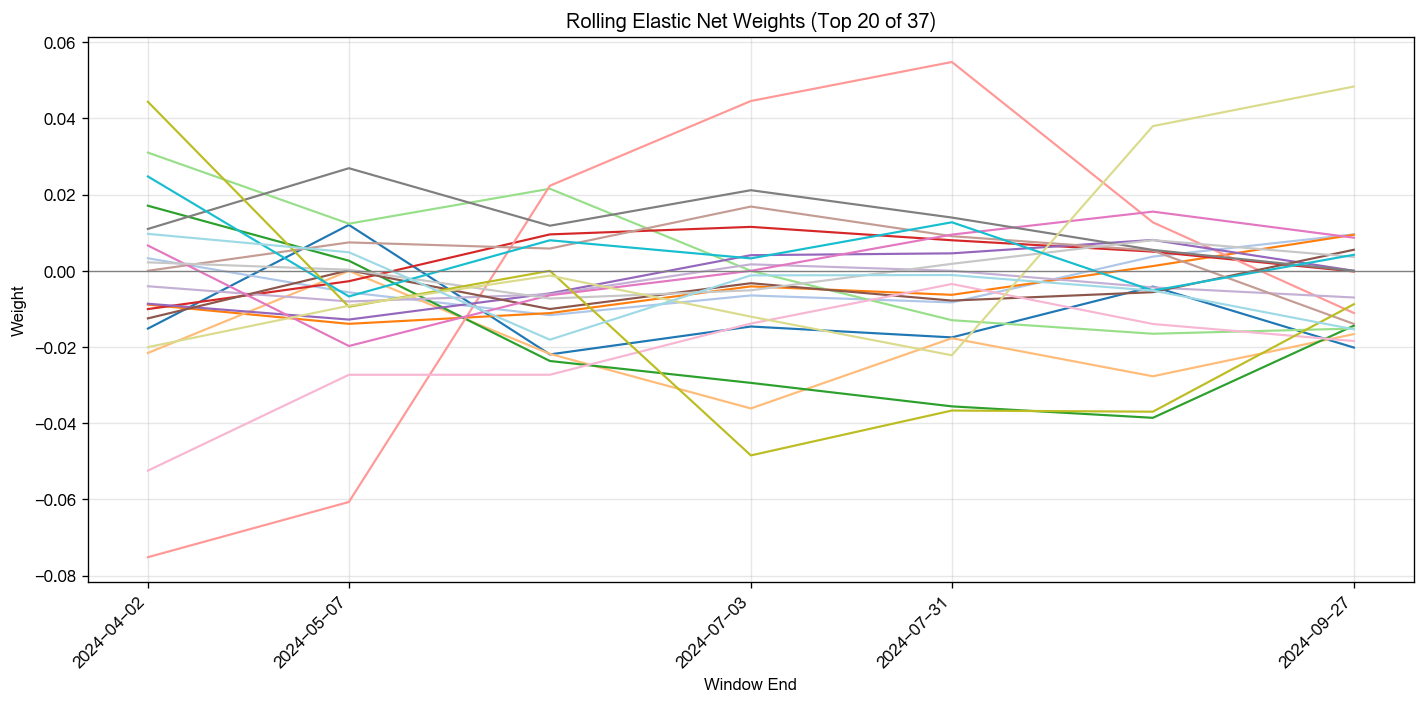
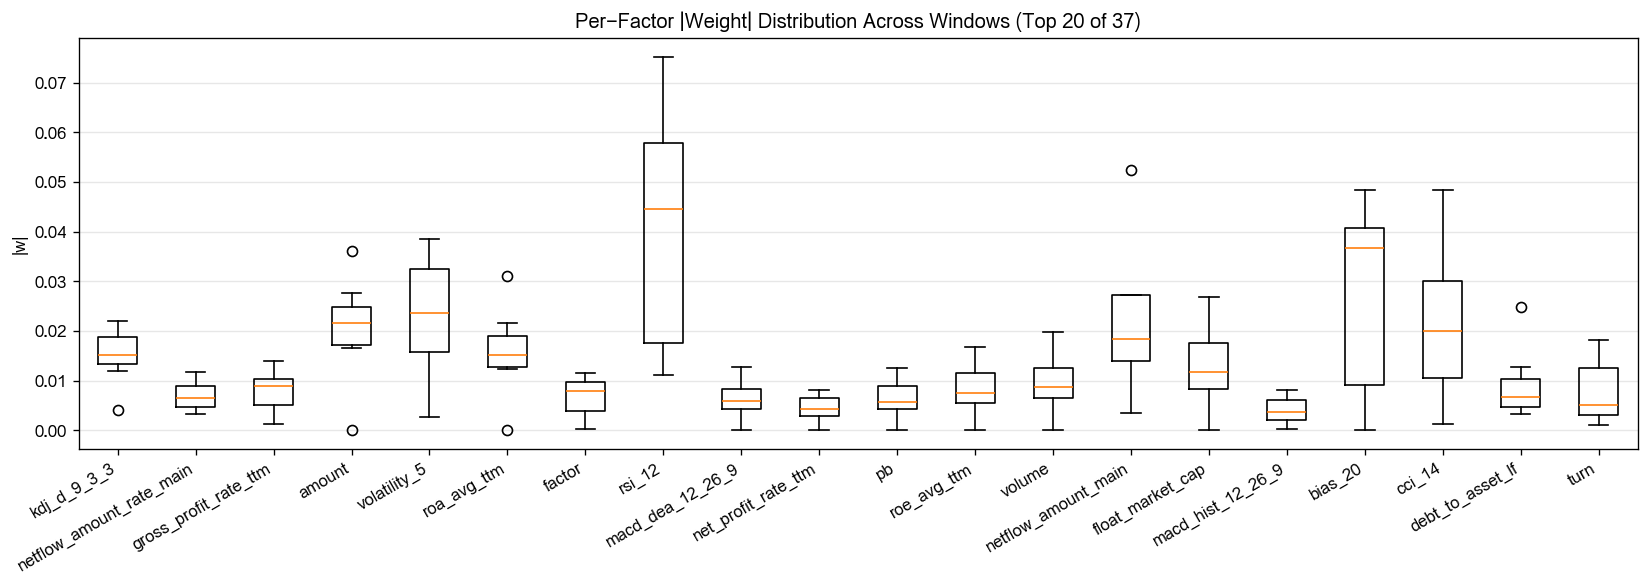
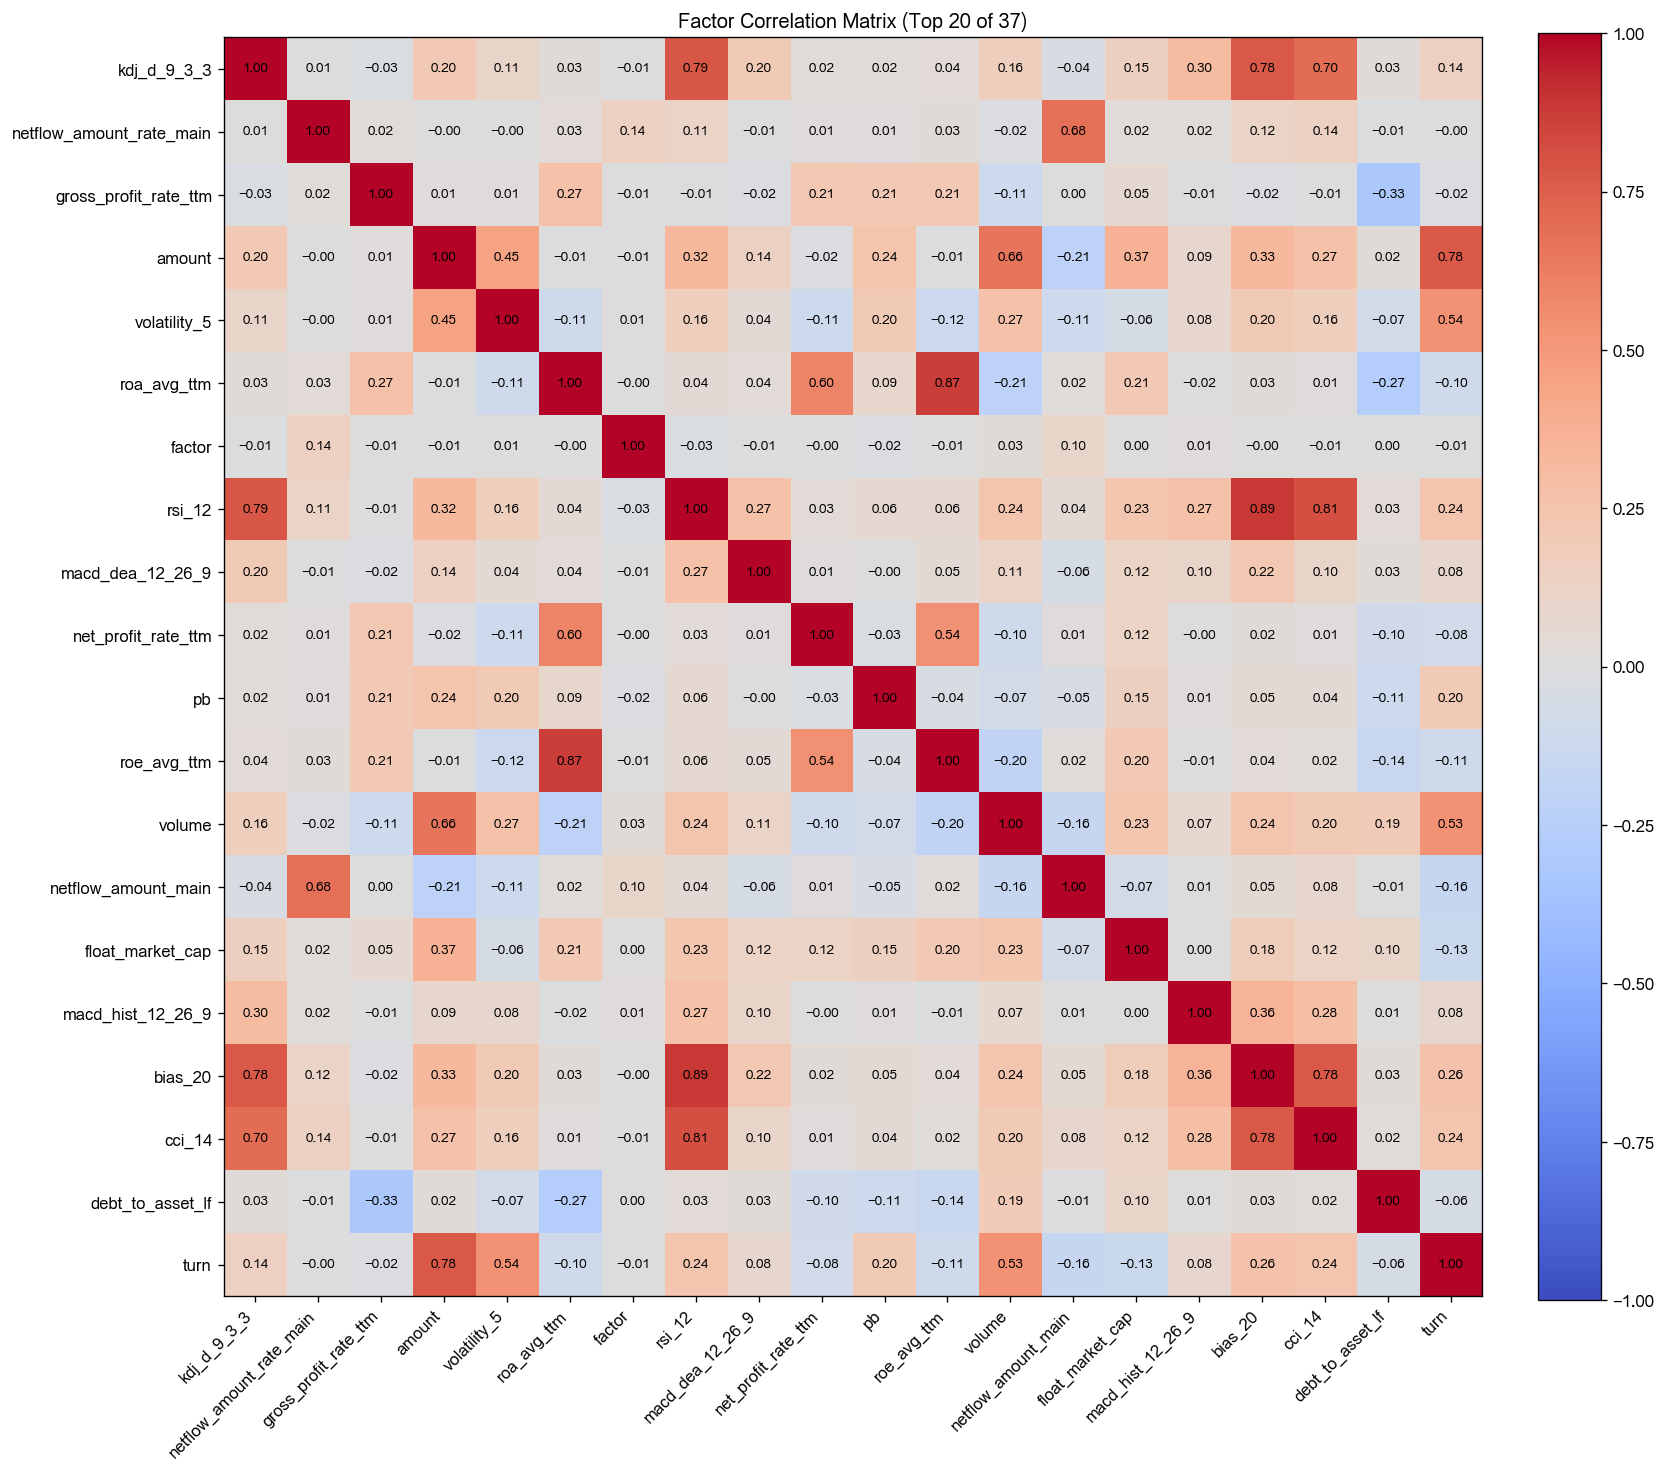

[2026-08-05 18:14:55] [warning  ] 返回的Outputs实例(size=28952694) 大于 64K, 将不会被缓存
[2026-08-05 18:14:55] [info     ] bigalpha_eval.v4 运行完成 [212.745s].


In [1]:
def main(datasources, start_date, end_date):
    """
    BigAlpha conservative microstructure factor.

    Design goals:
    - Keep SQL aggregation light enough for low-resource environments.
    - Use only current-day 1-minute L1 fields, with no look-ahead.
    - Preserve the official stock-pool panel to avoid completeness failures.
    - Return exactly ['date', 'instrument', 'factor'].
    """
    import numpy as np
    import pandas as pd
    import dai

    bar1m = datasources["bar1m"]

    sql = f"""
    WITH minute_feature AS (
        SELECT
            date::DATE::DATETIME AS date,
            instrument,
            date::TIME AS minute_time,
            (
                CAST(bid_volume1 AS DOUBLE) - CAST(ask_volume1 AS DOUBLE)
            ) / NULLIF(
                CAST(bid_volume1 AS DOUBLE) + CAST(ask_volume1 AS DOUBLE),
                0
            ) AS book_pressure,
            (
                CAST(ask_price1 AS DOUBLE) - CAST(bid_price1 AS DOUBLE)
            ) / NULLIF(
                (CAST(ask_price1 AS DOUBLE) + CAST(bid_price1 AS DOUBLE)) / 2.0,
                0
            ) AS rel_spread,
            (
                CAST(close AS DOUBLE) - CAST(open AS DOUBLE)
            ) / NULLIF(CAST(open AS DOUBLE), 0) AS minute_ret
        FROM {bar1m}
        WHERE
            open > 0
            AND bid_volume1 IS NOT NULL
            AND ask_volume1 IS NOT NULL
            AND bid_price1 IS NOT NULL
            AND ask_price1 IS NOT NULL
    )
    SELECT
        date,
        instrument,
        AVG(book_pressure) AS avg_pressure,
        AVG(
            CASE
                WHEN minute_time <= TIME '10:00:00'
                THEN book_pressure
                ELSE NULL
            END
        ) AS open_pressure,
        AVG(rel_spread) AS avg_spread,
        AVG(book_pressure * minute_ret) AS pressure_ret,
        COUNT(*) AS n_minutes
    FROM minute_feature
    GROUP BY date, instrument
    ORDER BY date, instrument
    """

    raw = dai.query(
        sql,
        filters={"date": [start_date, end_date]},
        compression=True,
    ).df()

    if raw.empty:
        raw = pd.DataFrame(
            columns=[
                "date",
                "instrument",
                "avg_pressure",
                "open_pressure",
                "avg_spread",
                "pressure_ret",
                "n_minutes",
            ]
        )

    raw["date"] = pd.to_datetime(raw["date"], errors="coerce").dt.normalize()
    if "instrument" in raw.columns:
        raw["instrument"] = raw["instrument"].astype(str)

    numeric_cols = [
        "avg_pressure",
        "open_pressure",
        "avg_spread",
        "pressure_ret",
        "n_minutes",
    ]
    for col in numeric_cols:
        raw[col] = pd.to_numeric(raw[col], errors="coerce")

    # Basic microstructure signal:
    # - Higher bid-side depth pressure is positive.
    # - Early-session pressure is useful because it is less diluted by late noise.
    # - Wide spread is penalized as weak liquidity.
    # - If pressure already pushes same-minute returns, part of the signal may be spent.
    raw["raw_factor"] = (
        0.55 * raw["avg_pressure"].fillna(0.0)
        + 0.35 * raw["open_pressure"].fillna(0.0)
        - 0.08 * raw["avg_spread"].fillna(0.0)
        - 0.02 * raw["pressure_ret"].fillna(0.0)
    )

    # Damp incomplete days instead of deleting them.
    raw["raw_factor"] *= np.clip(raw["n_minutes"].fillna(0.0) / 240.0, 0.3, 1.0)
    raw["raw_factor"] = pd.to_numeric(raw["raw_factor"], errors="coerce").replace(
        [np.inf, -np.inf],
        np.nan,
    )

    # Daily cross-sectional robust normalization. This is done before pool alignment;
    # after alignment we fill any missing stocks to keep the official panel complete.
    def normalize(group):
        value = group["raw_factor"]
        med = value.median()
        mad = (value - med).abs().median()
        if pd.isna(mad) or mad == 0:
            mad = 1e-8
        clipped = value.clip(med - 5 * mad, med + 5 * mad)
        std = clipped.std()
        if pd.isna(std) or std == 0:
            std = 1e-8
        group["factor"] = (clipped - clipped.mean()) / std
        return group

    raw = raw.groupby("date", group_keys=False).apply(normalize)
    raw = raw[["date", "instrument", "factor"]]
    raw["factor"] = pd.to_numeric(raw["factor"], errors="coerce").replace(
        [np.inf, -np.inf],
        np.nan,
    )

    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
        compression=True,
    ).df()
    stk_pool["date"] = pd.to_datetime(stk_pool["date"], errors="coerce").dt.normalize()
    stk_pool["instrument"] = stk_pool["instrument"].astype(str)
    stk_pool = stk_pool[["date", "instrument"]].drop_duplicates()

    out = pd.merge(stk_pool, raw, how="left", on=["date", "instrument"])

    # Keep missing-rate safely below the competition threshold. Median fill is neutral
    # after cross-sectional normalization; all-NaN dates fall back to 0.
    out["factor"] = out.groupby("date")["factor"].transform(lambda s: s.fillna(s.median()))
    out["factor"] = pd.to_numeric(out["factor"], errors="coerce").replace(
        [np.inf, -np.inf],
        np.nan,
    )
    out["factor"] = out["factor"].fillna(0.0).astype("float32")

    return out[["date", "instrument", "factor"]].sort_values(
        ["date", "instrument"]
    ).reset_index(drop=True)


if __name__ == "__main__":
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {
        "bar1m": "bigalpha_2026_stock_bar1m_selftest",
    }
    start_date = "2024-01-01 00:00:00"
    end_date = "2024-10-31 23:59:59"

    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        start_date=start_date,
        end_date=end_date,
        process_pools=False,
        show=True,
    )
